In [2]:
import pandas as pd
import numpy as np

import re

import nltk

from nltk.corpus import stopwords

from nltk.stem import WordNetLemmatizer


from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report
)


import torch

import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from collections import Counter

In [2]:
nltk.download('stopwords')

nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Komal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Komal\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
df = pd.read_csv(r"C:\Users\Komal\OneDrive\Desktop\commenttoxicity\data\train.csv")
df

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0


In [4]:
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [6]:
df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
len(df)

159571

In [9]:
x= df.iloc[:,2:].sum()
x

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [10]:
no_label_count =0

for i, count in x.items():
    if count ==0:
        no_label_count += 1 
print ('Total number of comments :', len(df))
print('Total number of comments without labels:', no_label_count)
print('Total labels:', x.sum())

Total number of comments : 159571
Total number of comments without labels: 0
Total labels: 35098


C:\Users\Komal\AppData\Local\Temp\ipykernel_94796\3638372900.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=x.index, y=x.values, alpha=0.8, palette=['tab:blue', 'tab:orange', 'tab:green', 'tab:brown', 'tab:red', 'tab:grey'])


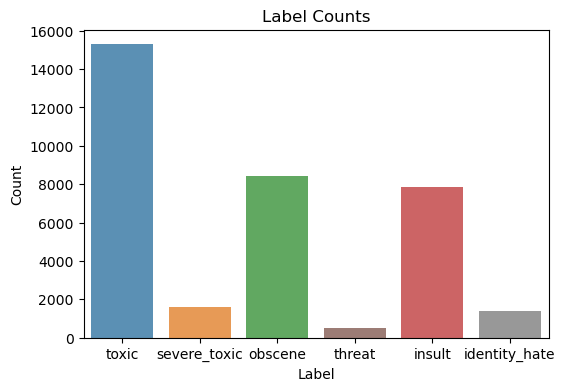

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=x.index, y=x.values, alpha=0.8, palette=['tab:blue', 'tab:orange', 'tab:green', 'tab:brown', 'tab:red', 'tab:grey'])
plt.title('Label Counts')
plt.ylabel('Count')
plt.xlabel('Label')

plt.show()

In [12]:
df = df.drop(columns=['id'], axis=1)
df.head()


,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [13]:
df = df[['comment_text', 'toxic']]

In [14]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [15]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z]", " ", text)

    words = text.split()

    words = [

        word for word in words

        if word not in stop_words
    ]

    words = [

        lemmatizer.lemmatize(word)

        for word in words
    ]

    return words

In [16]:
df['tokens'] = df['comment_text'].apply(clean_text)

In [17]:
all_words = []

for tokens in df['tokens']:

    all_words.extend(tokens)

In [18]:
word_counts = Counter(all_words)

In [19]:
# word index
vocab = {

    word: idx + 1

    for idx, (word, count)

    in enumerate(word_counts.items())
}

In [20]:
def text_to_sequence(tokens):

    return [

        vocab[word]

        for word in tokens

        if word in vocab
    ]

In [21]:
df['sequence'] = df['tokens'].apply(text_to_sequence)
def pad_sequence(seq, max_len):

    # If sequence is shorter than max_len
    if len(seq) < max_len:

        # Add zeros at the end
        seq = seq + [0] * (max_len - len(seq))

    else:
        # If sequence is longer, cut extra words
        seq = seq[:max_len]

    return seq

max_len = 100
df['padded'] = df['sequence'].apply(

    lambda x: pad_sequence(x, max_len)
)

In [22]:
df['sequence'][0]

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23]

In [23]:
X = np.array(df['padded'].tolist())

y = np.array(df['toxic'])

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [24]:
#convert to tensor
X_train = torch.tensor(X_train, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.long)

y_train = torch.tensor(y_train, dtype=torch.float32)

y_test = torch.tensor(y_test, dtype=torch.float32)

In [25]:
class ToxicDataset(Dataset):

    def __init__(self, X, y):

        self.X = X

        self.y = y


    def __len__(self):

        return len(self.X)


    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

In [26]:
train_dataset = ToxicDataset(X_train, y_train)

test_dataset = ToxicDataset(X_test, y_test)

In [27]:
train_loader = DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=True
)

In [28]:
test_loader = DataLoader(

    test_dataset,

    batch_size=64
)

In [29]:
class LSTMModel(nn.Module):

    def __init__(self, vocab_size):

        super(LSTMModel, self).__init__()


        self.embedding = nn.Embedding(

            vocab_size,

            128
        )


        self.lstm = nn.LSTM(

            input_size=128,

            hidden_size=64,

            batch_first=True
        )


        self.dropout = nn.Dropout(0.3)


        self.fc1 = nn.Linear(64, 32)

        self.fc2 = nn.Linear(32, 1)


        self.relu = nn.ReLU()

        self.sigmoid = nn.Sigmoid()


    def forward(self, x):

        x = self.embedding(x)

        output, (hidden, cell) = self.lstm(x)

        hidden = hidden[-1]

        x = self.dropout(hidden)

        x = self.fc1(x)

        x = self.relu(x)

        x = self.fc2(x)

        x = self.sigmoid(x)

        return x

In [33]:
# vocabulary size
vocab_size = len(vocab) + 1


# initialize model
model = LSTMModel(vocab_size)

criterion = nn.BCELoss()


# optimizer
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001
)

epochs = 10
for epoch in range(epochs):

    # training mode
    model.train()

    total_loss = 0


    for inputs, labels in train_loader:


        
        optimizer.zero_grad()


       
        outputs = model(inputs).squeeze()


        
        loss = criterion(outputs, labels)


       
        loss.backward()


        
        optimizer.step()


        
        total_loss += loss.item()


        avg_loss = total_loss / len(train_loader)

    print(

    f"Epoch {epoch+1}, Average Loss: {avg_loss:.4f}"
    )

Epoch 1, Average Loss: 0.2146
Epoch 2, Average Loss: 0.1176
Epoch 3, Average Loss: 0.0863
Epoch 4, Average Loss: 0.0632
Epoch 5, Average Loss: 0.0451
Epoch 6, Average Loss: 0.0321
Epoch 7, Average Loss: 0.0241
Epoch 8, Average Loss: 0.0190
Epoch 9, Average Loss: 0.0143
Epoch 10, Average Loss: 0.0120


In [34]:
from torch.utils.data import Dataset, DataLoader
class ToxicDataset(Dataset):

    def __init__(self, X, y):

        self.X = X

        self.y = y


    def __len__(self):

        return len(self.X)


    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]
    test_dataset = ToxicDataset(

    X_test,

    y_test
)
    
test_loader = DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False
)

In [35]:
model.eval()
predictions = []

actuals = []

with torch.no_grad():

    for inputs, labels in test_loader:

        outputs = model(inputs).squeeze()

        preds = (outputs > 0.5).int()

        predictions.extend(preds.tolist())

        actuals.extend(labels.tolist())

    

In [36]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [37]:
accuracy = accuracy_score(

    actuals,

    predictions
)

print("Accuracy:", accuracy)

print(

    classification_report(

        actuals,

        predictions
    )
)


Accuracy: 0.9523421588594705
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97     28856
         1.0       0.78      0.70      0.74      3059

    accuracy                           0.95     31915
   macro avg       0.87      0.84      0.86     31915
weighted avg       0.95      0.95      0.95     31915



In [38]:
accuracy = accuracy_score(

    actuals,

    predictions
)
print("LSTM Accuracy:")

print(accuracy)

LSTM Accuracy:
0.9523421588594705


In [39]:
def predict_toxicity(text):

    tokens = clean_text(text)

    sequence = text_to_sequence(tokens)

    padded = pad_sequence(sequence, max_len)


    tensor = torch.tensor(

        [padded],

        dtype=torch.long
    )


    model.eval()


    with torch.no_grad():

        output = model(tensor).item()


    if output < 0.2:

        label = " Safe"

    elif output < 0.5:

        label = "Suspicious"

    else:

        label = "Toxic"


    return label, output

In [40]:
test_comments = [

    "You are amazing.",

    "I hate you idiot.",

    "Nobody likes you.",

    "You are useless."
]

In [43]:
for comment in test_comments:

    label, score = predict_toxicity(comment)

    print("\nComment:")

    print(comment)

    print("\nPrediction:")

    print(label)

    print("\nToxicity Score:")

    print(round(score * 100, 2), "%")

    print("\n" + "="*6)


Comment:
You are amazing.

Prediction:
 Safe

Toxicity Score:
0.0 %


Comment:
I hate you idiot.

Prediction:
Toxic

Toxicity Score:
99.98 %


Comment:
Nobody likes you.

Prediction:
 Safe

Toxicity Score:
3.46 %


Comment:
You are useless.

Prediction:
Toxic

Toxicity Score:
92.65 %



In [44]:
torch.save(

    model.state_dict(),

    "lstm_model.pth"
)

In [45]:
import pickle
with open("vocab.pkl", "wb") as f:

    pickle.dump(vocab, f)